<a href="https://colab.research.google.com/github/luiscalvi/CSC349/blob/main/HW2/data_prep_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

df = pd.read_csv('cybersecurity_intrusion_data.csv')

df.head()

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   object 
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   object 
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 819.7+ KB


In [4]:
df.describe()

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
count,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000
mean,500.430639,4.032086,792.745312,0.331338,1.517773,0.149942,0.447101
std,198.379364,1.963012,786.560144,0.177175,1.033988,0.357034,0.497220
min,64.000000,1.000000,0.500000,0.002497,0.000000,0.000000,0.000000
25%,365.000000,3.000000,231.953006,0.191946,1.000000,0.000000,0.000000
50%,499.000000,4.000000,556.277457,0.314778,1.000000,0.000000,0.000000
75%,635.000000,5.000000,1105.380602,0.453388,2.000000,0.000000,1.000000
max,1285.000000,13.000000,7190.392213,0.924299,5.000000,1.000000,1.000000


In [5]:
print(df.columns)

Index(['session_id', 'network_packet_size', 'protocol_type', 'login_attempts',
       'session_duration', 'encryption_used', 'ip_reputation_score',
       'failed_logins', 'browser_type', 'unusual_time_access',
       'attack_detected'],
      dtype='object')


In [6]:
df.isnull().sum()

,0
session_id,0
network_packet_size,0
protocol_type,0
login_attempts,0
session_duration,0
encryption_used,1966
ip_reputation_score,0
failed_logins,0
browser_type,0
unusual_time_access,0


In [7]:
df = df.drop(columns=['session_id'])

In [8]:
X = df.drop(columns=['attack_detected'])
y = df['attack_detected']

In [10]:
#Isolating Numberical Features
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

print(numerical_features)

Index(['network_packet_size', 'login_attempts', 'session_duration',
       'ip_reputation_score', 'failed_logins', 'unusual_time_access'],
      dtype='object')


In [11]:
#Isolating categorical features
categorical_features = X.select_dtypes(include=['object', 'category']).columns

print(categorical_features)

Index(['protocol_type', 'encryption_used', 'browser_type'], dtype='object')


In [12]:
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [13]:
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [14]:
preprocessor = ColumnTransformer([
    ('numerical', numerical_pipeline, numerical_features),
    ('categorical', categorical_pipeline, categorical_features)
])

In [15]:
X_processed = preprocessor.fit_transform(X)

print(X_processed.shape)

(9537, 16)


In [16]:
#Pearson Correlation

correlation_matrix = df.select_dtypes(include=['int64', 'float64']).corr()

correlation_matrix

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
network_packet_size,1.000000,-0.001890,0.021650,0.002320,-0.011676,-0.001255,-0.006798
login_attempts,-0.001890,1.000000,0.006392,-0.002618,-0.013507,0.007349,0.277320
session_duration,0.021650,0.006392,1.000000,-0.005077,0.019375,0.012930,0.041602
ip_reputation_score,0.002320,-0.002618,-0.005077,1.000000,0.015613,-0.003146,0.211540
failed_logins,-0.011676,-0.013507,0.019375,0.015613,1.000000,0.006131,0.363726
unusual_time_access,-0.001255,0.007349,0.012930,-0.003146,0.006131,1.000000,0.008652
attack_detected,-0.006798,0.277320,0.041602,0.211540,0.363726,0.008652,1.000000


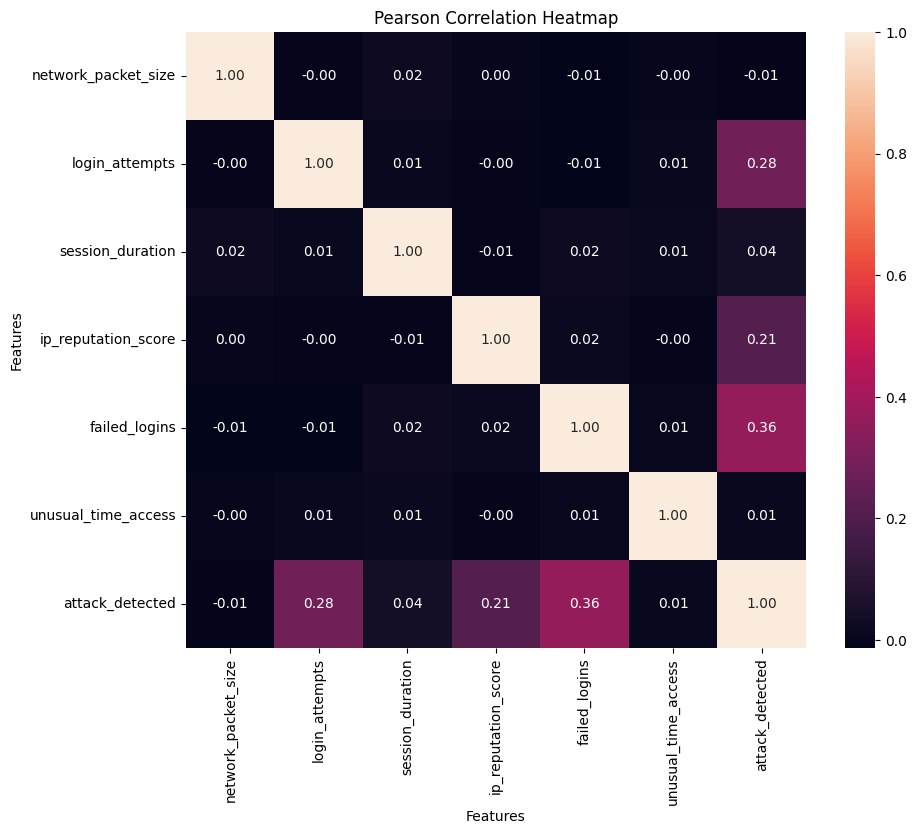

In [17]:
#Heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f'
)

plt.title('Pearson Correlation Heatmap')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()

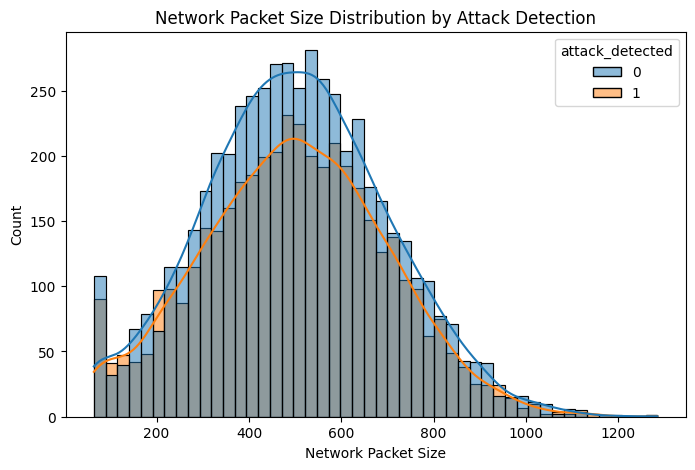

In [18]:
#First Distribution Plot

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='network_packet_size',
    hue='attack_detected',
    kde=True
)

plt.title('Network Packet Size Distribution by Attack Detection')
plt.xlabel('Network Packet Size')
plt.ylabel('Count')
plt.show()

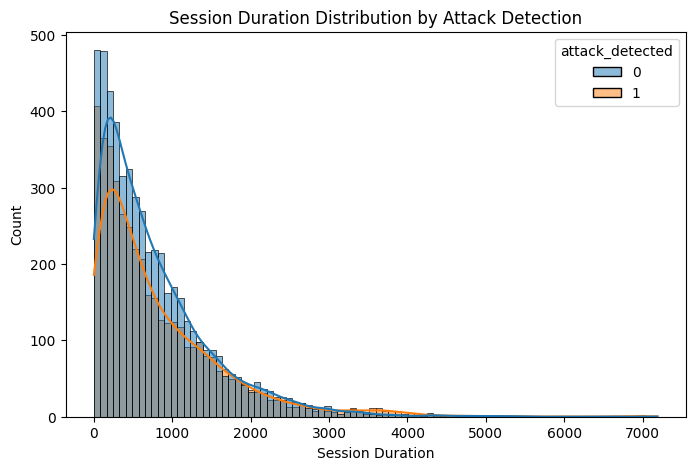

In [19]:
#Second Distribution Plot

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='session_duration',
    hue='attack_detected',
    kde=True
)

plt.title('Session Duration Distribution by Attack Detection')
plt.xlabel('Session Duration')
plt.ylabel('Count')
plt.show()

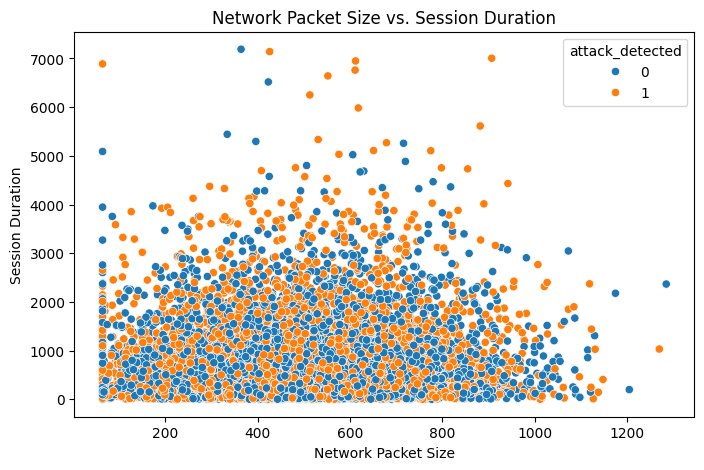

In [20]:
#Scatterplot
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='network_packet_size',
    y='session_duration',
    hue='attack_detected'
)

plt.title('Network Packet Size vs. Session Duration')
plt.xlabel('Network Packet Size')
plt.ylabel('Session Duration')
plt.show()